In [93]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import sys
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
import pandas as pd
from qutip import *
import krotov
import scipy.constants
import pickle
from tkinter import filedialog # for prompting user to set analysis folder
import glob
# import lyse
import h5py
from pathlib import PureWindowsPath, PurePosixPath
from tqdm import tqdm
from joblib import Parallel, delayed
import numba
from sympy.physics.wigner import wigner_3j, wigner_6j
from lmfit import Model, Parameters
from scipy.special import jn, jn_zeros

# analysis_directory = '/Users/huanbui/Documents/GitHub/labscript-suite/userlib/analysislib/common/analysis_scripts'
# sys.path.append(analysis_directory)

# image_utils_directory = '/Users/huanbui/Documents/GitHub/labscript-suite/userlib/analysislib/common/image_utils'
# sys.path.append(image_utils_directory)

# from analysis_utility_functions import *
# from analysis_ROI_finding_functions import *
# from analysis_functions import *

In [94]:
def normalized_airy_disk(x, y, NA = 0.7, lam = 0.589, imaging_magnification = 50):
    R = 0.61 * lam / NA # radius of first zero
    Rz = 1.2196698912665045
    u = np.pi * np.sqrt(x**2 + y**2) / (R/Rz) # distances in pixels
    u = (u / imaging_magnification)
    return (2 * jn(1, u) / u)**2

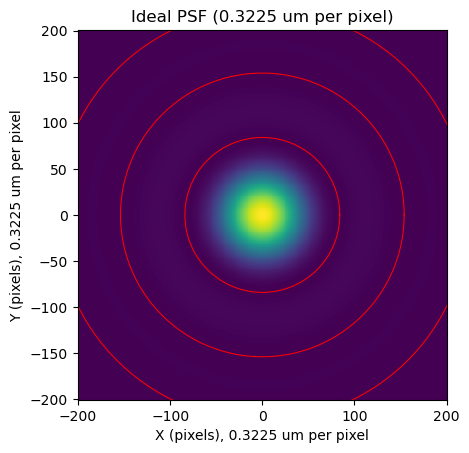

In [148]:
# get ideal PSF in real space, oversampled
# lengths are in units of lambda
imaging_magnification = (430 / 35) * (430/100)
camera_magnification = 6.45 # um per pixel
fake_camera_magnification = camera_magnification/20
lam = 0.589
NA = 0.7

x = np.linspace(-200, 200, 400) # fake pixels
y = np.linspace(-200, 200, 400) # fake pixels
theta = np.linspace(0, 2*np.pi, 180)

X, Y = np.meshgrid(x,y)

ideal_PSF = normalized_airy_disk(X*fake_camera_magnification,Y*fake_camera_magnification, NA = NA, lam = lam, imaging_magnification= imaging_magnification)
plt.pcolormesh(X, Y, ideal_PSF)
plt.axis('scaled')
plt.xlabel('X (pixels), 0.3225 um per pixel')
plt.ylabel('Y (pixels), 0.3225 um per pixel')
# plot the zero contours
for z in jn_zeros(1, 10) / (2*np.pi):
    plt.plot(imaging_magnification*z*lam / NA * np.cos(theta) / fake_camera_magnification, 
             imaging_magnification*z*lam / NA * np.sin(theta) / fake_camera_magnification, 
             color = 'red', linewidth = 0.75)
plt.title('Ideal PSF (0.3225 um per pixel)')
plt.show()

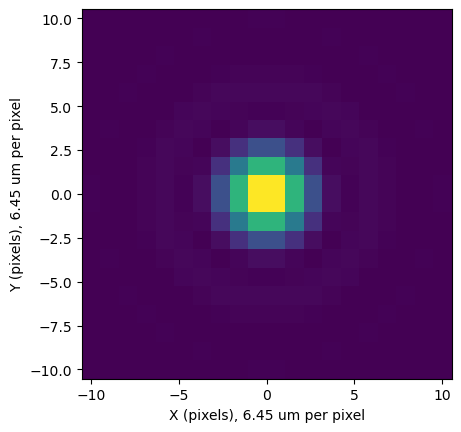

In [151]:
sampled_airy = ideal_PSF.reshape(20, 20, 20, 20).sum(3).sum(1)
new_x = np.linspace(-10,10,20)
new_y = np.linspace(-10,10,20)
new_X, new_Y = np.meshgrid(new_x, new_y)
plt.pcolormesh(new_X, new_Y, sampled_airy)
sampled_airy.shape
plt.axis('scaled')
plt.xlabel('X (pixels), 6.45 um per pixel')
plt.ylabel('Y (pixels), 6.45 um per pixel')
plt.show()